🔍 GPU Detection...
⚠️  GPU یافت نشد. CPU استفاده می‌شود.

📊 GPU Information:
GPU Available: False
TensorFlow Version: 2.20.0

❌ مدل آموزش‌دیده یافت نشد!

1) آموزش مدل
2) خروج

🎓 شروع آموزش...

📊 GPU Information:
GPU Available: False
TensorFlow Version: 2.20.0

🖥️  TensorFlow 2.20.0
📱 Available Devices:
   - LogicalDevice(name='/device:CPU:0', device_type='CPU')

🔧 GPU devices: 0
🔧 CPU devices: 1
🎮  شروع آموزش DQN (TensorFlow) - بازی Catch with Gymnasium
📝  روش یادگیری: GradientTape (سریع)
💻 GPU Acceleration: غیرفعال (CPU Mode)


c:\Users\Ebi_Mahmdli\anaconda3\envs\ebi-env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


📊 اپیزود   100 │ میانگین: -0.06 │ برد:  47% [█████████░░░░░░░░░░░] │ ε: 0.606
📊 اپیزود   200 │ میانگین: +0.52 │ برد:  76% [███████████████░░░░░] │ ε: 0.367
📊 اپیزود   300 │ میانگین: +0.66 │ برد:  83% [████████████████░░░░] │ ε: 0.222
📊 اپیزود   400 │ میانگین: +0.82 │ برد:  91% [██████████████████░░] │ ε: 0.135
📊 اپیزود   500 │ میانگین: +0.92 │ برد:  96% [███████████████████░] │ ε: 0.082
📊 اپیزود   600 │ میانگین: +0.96 │ برد:  98% [███████████████████░] │ ε: 0.049
📊 اپیزود   700 │ میانگین: +0.98 │ برد:  99% [███████████████████░] │ ε: 0.030
📊 اپیزود   800 │ میانگین: +1.00 │ برد: 100% [████████████████████] │ ε: 0.018
📊 اپیزود   900 │ میانگین: +0.82 │ برد:  91% [██████████████████░░] │ ε: 0.011

✅ Epsilon به حداقل رسید (0.0110)! توقف آموزش...

💾 مدل ذخیره شد: model_weights.weights.h5


C:\Users\Ebi_Mahmdli\AppData\Local\Temp\ipykernel_26920\1513962977.py:434: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Ebi_Mahmdli\AppData\Local\Temp\ipykernel_26920\1513962977.py:434: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Ebi_Mahmdli\AppData\Local\Temp\ipykernel_26920\1513962977.py:435: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('results.png', dpi=150)
C:\Users\Ebi_Mahmdli\AppData\Local\Temp\ipykernel_26920\1513962977.py:435: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('results.png', dpi=150)
c:\Users\Ebi_Mahmdli\anaconda3\envs\ebi-env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

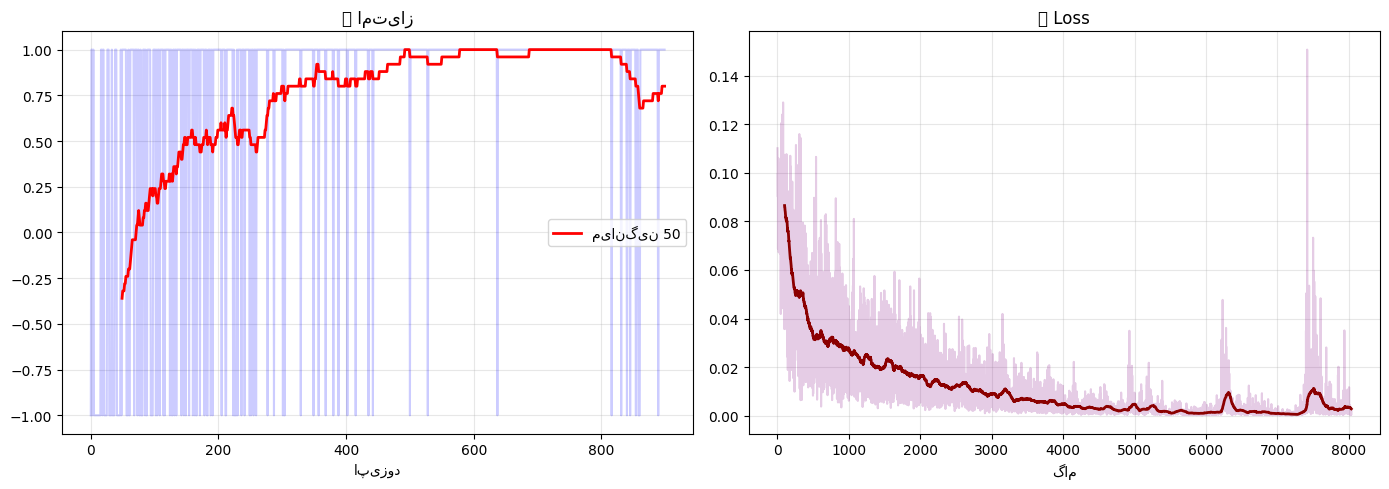

📊 ذخیره شد: results.png

▶️  شروع تماشای بازی...

🎮  تماشای بازی + یادگیری مستمر
⚙️  وزن‌ها و حافظه در حال آپدیت...
🎮 بازی 1/10
+----------+
|....O.....|
|..........|
|..........|
|..........|
|..........|
|..........|
|..........|
|..........|
|..........|
|....===...|
+----------+
عمل: ➡️ راست
🎮 بازی 1/10
+----------+
|..........|
|....O.....|
|..........|
|..........|
|..........|
|..........|
|..........|
|..........|
|..........|
|.....===..|
+----------+
عمل: ➡️ راست
🎮 بازی 1/10
+----------+
|..........|
|..........|
|....O.....|
|..........|
|..........|
|..........|
|..........|
|..........|
|..........|
|......===.|
+----------+
عمل: ⏸️ ثابت
🎮 بازی 1/10
+----------+
|..........|
|..........|
|..........|
|....O.....|
|..........|
|..........|
|..........|
|..........|
|..........|
|......===.|
+----------+
عمل: ⏸️ ثابت
🎮 بازی 1/10
+----------+
|..........|
|..........|
|..........|
|..........|
|....O.....|
|..........|
|..........|
|..........|
|..........|
|......===.|
+----

KeyboardInterrupt: 

In [1]:
import numpy as np
import random
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt
import os, time
import gymnasium as gym
from gymnasium import spaces

# ═══════════════════════════════════════════
#  GPU/CUDA Configuration
# ═══════════════════════════════════════════

# تشخیص و فعال کردن GPU
print("🔍 GPU Detection...")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ تعداد GPU یافت شده: {len(gpus)}")
    for gpu in gpus:
        print(f"   - {gpu}")
    
    # فعال کردن memory growth برای GPU
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth فعال شد")
    except RuntimeError as e:
        print(f"❌ خطا در تنظیم GPU: {e}")
    
    # تنظیم precision policy برای سرعت بیشتر
    policy = tf.keras.mixed_precision.Policy('mixed_float16')
    tf.keras.mixed_precision.set_global_policy(policy)
    print("✅ Mixed Precision (float16) فعال شد")
else:
    print("⚠️  GPU یافت نشد. CPU استفاده می‌شود.")

# نمایش اطلاعات GPU
def print_gpu_info():
    print("\n" + "="*55)
    print("📊 GPU Information:")
    print("="*55)
    gpus = tf.config.list_physical_devices('GPU')
    print(f"GPU Available: {len(gpus) > 0}")
    if gpus:
        for i, gpu in enumerate(gpus):
            print(f"  GPU {i}: {gpu}")
    print(f"TensorFlow Version: {tf.__version__}")
    print("="*55 + "\n")


# ═══════════════════════════════════════════
#  1. محیط بازی Gymnasium
# ═══════════════════════════════════════════

class CatchEnv(gym.Env):
    """Custom Catch game environment compatible with Gymnasium"""
    
    def __init__(self, grid_size=10):
        super(CatchEnv, self).__init__()
        self.grid_size = grid_size
        
        # تعریف فضای عمل و وضعیت
        self.action_space = spaces.Discrete(3)  # چپ، ثابت، راست
        self.observation_space = spaces.Box(
            low=0, high=1, shape=(3,), dtype=np.float32
        )  # [ball_x, ball_y, basket_x]
        
        self.reset()
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.game = {
            'ball_x': random.randint(0, self.grid_size - 1),
            'ball_y': 0,
            'basket_x': self.grid_size // 2,
            'done': False
        }
        return self._get_state(), {}
    
    def _get_state(self):
        return np.array([
            self.game['ball_x'] / self.grid_size,
            self.game['ball_y'] / self.grid_size,
            self.game['basket_x'] / self.grid_size
        ], dtype=np.float32)
    
    def step(self, action):
        # بروز رسانی سبد
        if action == 0:
            self.game['basket_x'] = max(0, self.game['basket_x'] - 1)
        elif action == 2:
            self.game['basket_x'] = min(self.grid_size - 1, self.game['basket_x'] + 1)
        
        # بروز رسانی موقعیت توپ
        self.game['ball_y'] += 1
        
        reward = 0.0
        terminated = False
        
        if self.game['ball_y'] >= self.grid_size - 1:
            terminated = True
            if abs(self.game['ball_x'] - self.game['basket_x']) <= 1:
                reward = 1.0
            else:
                reward = -1.0
        
        return self._get_state(), reward, terminated, False, {}
    
    def render(self):
        print("+" + "-" * self.grid_size + "+")
        for y in range(self.grid_size):
            row = ""
            for x in range(self.grid_size):
                if y == self.game['ball_y'] and x == self.game['ball_x']:
                    row += "O"
                elif y == self.grid_size - 1 and abs(x - self.game['basket_x']) <= 1:
                    row += "="
                else:
                    row += "."
            print("|" + row + "|")
        print("+" + "-" * self.grid_size + "+")
    
    def close(self):
        pass


GRID_SIZE = 10
STATE_SIZE = 3
ACTION_SIZE = 3

def reset_game():
    """برای سازگاری با کد قدیم"""
    return {
        'ball_x': random.randint(0, GRID_SIZE - 1),
        'ball_y': 0,
        'basket_x': GRID_SIZE // 2,
        'done': False
    }

def get_state(game):
    """برای سازگاری با کد قدیم"""
    return np.array([
        game['ball_x'] / GRID_SIZE,
        game['ball_y'] / GRID_SIZE,
        game['basket_x'] / GRID_SIZE
    ], dtype=np.float32)


# ═══════════════════════════════════════════
#  2. ساخت شبکه عصبی با Keras (GPU-Optimized)
# ═══════════════════════════════════════════

def build_network():
    """GPU-optimized network architecture"""
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(STATE_SIZE,), 
                            dtype='float32'),  # Input layer uses float32
        tf.keras.layers.Dense(128, activation='relu', dtype='float32'),
        tf.keras.layers.Dense(64, activation='relu', dtype='float32'),
        tf.keras.layers.Dense(ACTION_SIZE, activation='linear', dtype='float32')  # Output layer uses float32
    ])
    
    # استفاده از آپتیمایزر GPU-optimized
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, use_ema=True),  # EMA برای بهتری
        loss='mse',
        metrics=['mae']
    )
    return model

def copy_weights(source, target):
    """کپی وزن‌ها از شبکه مبدأ به هدف"""
    target.set_weights(source.get_weights())


# ═══════════════════════════════════════════
#  3. حافظه تجربه
# ═══════════════════════════════════════════

def create_memory(capacity=10000):
    return deque(maxlen=capacity)

def push_memory(memory, state, action, reward, next_state, done):
    memory.append((state, action, reward, next_state, done))

def sample_memory(memory, batch_size):
    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)
    return (
        np.array(states),
        np.array(actions),
        np.array(rewards, dtype=np.float32),
        np.array(next_states),
        np.array(dones, dtype=np.float32)
    )


# ═══════════════════════════════════════════
#  4. انتخاب عمل
# ═══════════════════════════════════════════

def select_action(state, policy_net, epsilon):
    """ε-greedy"""
    if random.random() < epsilon:
        return random.randrange(ACTION_SIZE)

    state_input = np.expand_dims(state, axis=0)       # (1, 3)
    q_values = policy_net.predict(state_input, verbose=0)  # (1, 3)
    return np.argmax(q_values[0])


# ═══════════════════════════════════════════
#  5. یادگیری
# ═══════════════════════════════════════════

def learn(memory, policy_net, target_net, batch_size=64, gamma=0.99):
    """
    Q_target = r + γ × max Q_target(s', a')
    """
    if len(memory) < batch_size:
        return None

    states, actions, rewards, next_states, dones = \
        sample_memory(memory, batch_size)

    # ── Q هدف ──
    next_q = target_net.predict(next_states, verbose=0)     # (64, 3)
    max_next_q = np.max(next_q, axis=1)                     # (64,)
    targets_value = rewards + (1 - dones) * gamma * max_next_q

    # ── Q فعلی ──
    current_q = policy_net.predict(states, verbose=0)        # (64, 3)

    # فقط مقدار عمل انتخاب‌شده را آپدیت کن
    for i in range(batch_size):
        current_q[i][actions[i]] = targets_value[i]

    # آموزش
    history = policy_net.fit(states, current_q, batch_size=batch_size, epochs=1, verbose=0)
    return history.history['loss'][0]


# ═══════════════════════════════════════════
#  5.5 یادگیری سریع‌تر با GradientTape
# ═══════════════════════════════════════════

# اگه خواستی سریع‌تر باشه از این نسخه استفاده کن:

optimizer_global = tf.keras.optimizers.Adam(learning_rate=0.001, use_ema=True)
loss_fn = tf.keras.losses.MeanSquaredError()

@tf.function  # GPU optimization: compile to graph
def _train_step(states_t, actions, rewards, next_states_t, dones, policy_net, target_net, batch_size, gamma):
    # Q هدف
    next_q = target_net(next_states_t, training=False)
    max_next_q = tf.reduce_max(next_q, axis=1)
    target_q = rewards + (1 - dones) * gamma * max_next_q

    with tf.GradientTape() as tape:
        # Q فعلی
        all_q = policy_net(states_t, training=True)           # (64, 3)
        indices = tf.stack([
            tf.range(batch_size, dtype=tf.int32),
            tf.cast(actions, tf.int32)
        ], axis=1)
        predicted_q = tf.gather_nd(all_q, indices)            # (64,)

        loss = loss_fn(target_q, predicted_q)

    # بهینه‌سازی
    grads = tape.gradient(loss, policy_net.trainable_variables)
    # Gradient Clipping
    grads = [tf.clip_by_norm(g, 1.0) for g in grads]
    optimizer_global.apply_gradients(zip(grads, policy_net.trainable_variables))

    return loss

def learn_fast(memory, policy_net, target_net, batch_size=64, gamma=0.99):
    """نسخه سریع‌تر با GradientTape - GPU Optimized"""
    if len(memory) < batch_size:
        return None

    states, actions, rewards, next_states, dones = \
        sample_memory(memory, batch_size)

    states_t = tf.convert_to_tensor(states, dtype=tf.float32)
    next_states_t = tf.convert_to_tensor(next_states, dtype=tf.float32)

    loss = _train_step(states_t, actions, rewards, next_states_t, dones, policy_net, target_net, batch_size, gamma)
    return float(loss.numpy())


# ═══════════════════════════════════════════
#  6. آموزش (GPU-Accelerated)
# ═══════════════════════════════════════════

def train(use_fast=True):
    print_gpu_info()
    print(f"🖥️  TensorFlow {tf.__version__}")
    
    # نمایش GPU و CPU devices
    print("📱 Available Devices:")
    for device in tf.config.list_logical_devices():
        print(f"   - {device}")
    print()
    
    gpus = tf.config.list_physical_devices('GPU')
    cpu_devices = tf.config.list_physical_devices('CPU')
    print(f"🔧 GPU devices: {len(gpus)}")
    print(f"🔧 CPU devices: {len(cpu_devices)}")

    # ساخت شبکه‌ها
    policy_net = build_network()
    target_net = build_network()
    copy_weights(policy_net, target_net)

    memory = create_memory(10000)

    # ایجاد محیط Gymnasium
    env = CatchEnv(grid_size=GRID_SIZE)

    # هایپرپارامترها
    epsilon = 1.0
    epsilon_min = 0.01
    epsilon_decay = 0.995
    gamma = 0.99
    batch_size = 64
    target_update = 10
    num_episodes = 2000

    all_scores = []
    all_losses = []
    avg_scores = []
    win_count = 0

    # انتخاب تابع یادگیری
    learn_func = learn_fast if use_fast else learn

    print("=" * 55)
    print("🎮  شروع آموزش DQN (TensorFlow) - بازی Catch with Gymnasium")
    print(f"📝  روش یادگیری: {'GradientTape (سریع)' if use_fast else 'model.fit'}")
    if gpus:
        print(f"🚀 GPU Acceleration: فعال ({len(gpus)} GPU)")
    else:
        print("💻 GPU Acceleration: غیرفعال (CPU Mode)")
    print("=" * 55)

    for episode in range(1, num_episodes + 1):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = select_action(state, policy_net, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            push_memory(memory, state, action, reward, next_state, float(done))

            loss = learn_func(memory, policy_net, target_net, batch_size, gamma)
            if loss is not None:
                all_losses.append(loss)

            state = next_state
            total_reward += reward

        # بعد از اپیزود
        all_scores.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if total_reward > 0:
            win_count += 1

        # آپدیت شبکه هدف
        if episode % target_update == 0:
            copy_weights(policy_net, target_net)

        # چاپ
        if episode % 100 == 0:
            avg = np.mean(all_scores[-100:])
            avg_scores.append(avg)
            wr = win_count
            bar = "█" * (wr // 5) + "░" * (20 - wr // 5)

            print(f"📊 اپیزود {episode:5d} │ " f"میانگین: {avg:+.2f} │ " f"برد: {wr:3d}% [{bar}] │ " f"ε: {epsilon:.3f}")
            win_count = 0
        
        # اگر epsilon به حداقل رسید، توقف آموزش و شروع بازی
        if epsilon <= epsilon_min + 0.001:  # کمی حاشیه برای دقت
            print(f"\n✅ Epsilon به حداقل رسید ({epsilon:.4f})! توقف آموزش...")
            break

    env.close()

    # ذخیره
    policy_net.save_weights("model_weights.weights.h5")
    print("\n💾 مدل ذخیره شد: model_weights.weights.h5")
    
    # پاک کردن GPU memory
    if gpus:
        print("🧹 Clearing GPU memory...")
        tf.keras.backend.clear_session()

    plot_training(all_scores, avg_scores, all_losses)
    return policy_net, target_net, memory


# ═══════════════════════════════════════════
#  7. رسم نمودار
# ═══════════════════════════════════════════

def plot_training(scores, avg_scores, losses):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(scores, alpha=0.2, color='blue')
    w = 50
    if len(scores) >= w:
        ma = np.convolve(scores, np.ones(w) / w, mode='valid')
        ax1.plot(range(w - 1, len(scores)), ma, color='red', linewidth=2, label=f'میانگین {w}')
    ax1.set_title('📈 امتیاز')
    ax1.set_xlabel('اپیزود')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    if losses:
        ax2.plot(losses, alpha=0.2, color='purple')
        if len(losses) >= 100:
            la = np.convolve(losses, np.ones(100) / 100, mode='valid')
            ax2.plot(range(99, len(losses)), la, color='darkred', linewidth=2)
    ax2.set_title('📉 Loss')
    ax2.set_xlabel('گام')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results.png', dpi=150)
    plt.show()
    print("📊 ذخیره شد: results.png")


# ═══════════════════════════════════════════
#  8. تماشای بازی با یادگیری
# ═══════════════════════════════════════════

def play(num_games=10, policy_net=None, target_net=None, memory=None, learn_func=None):
    """
    تماشای بازی و هم‌زمان یادگیری
    
    اگر policy_net و target_net و memory فراهم شود، 
    وزن‌ها طی بازی آپدیت می‌شوند
    """
    
    # اگر شبکه فراهم نشود، بارگذاری کن
    if policy_net is None:
        policy_net = build_network()
        
        if not os.path.exists("model_weights.weights.h5"):
            print("❌ خطا: فایل وزن‌های مدل یافت نشد!")
            print("لطفاً ابتدا مدل را آموزش دهید (گزینه 1)")
            return
        
        policy_net.load_weights("model_weights.weights.h5")
        continue_learning = False
    else:
        continue_learning = True
        if target_net is None or memory is None or learn_func is None:
            continue_learning = False

    # ایجاد محیط Gymnasium
    env = CatchEnv(grid_size=GRID_SIZE)

    wins = 0
    names = ["⬅️ چپ", "⏸️ ثابت", "➡️ راست"]

    print("\n" + "=" * 50)
    if continue_learning:
        print("🎮  تماشای بازی + یادگیری مستمر")
        print("⚙️  وزن‌ها و حافظه در حال آپدیت...")
    else:
        print("🎮  تماشای بازی (بدون یادگیری)")
    print("=" * 50)

    # هایپرپارامترهای یادگیری در حین بازی
    gamma = 0.99
    batch_size = 64
    epsilon_play = 0.05  # برای کمی اکتشاف
    
    target_update_play = 5
    game_count = 0

    for g in range(1, num_games + 1):
        state, _ = env.reset()
        done = False

        while not done:
            os.system('cls' if os.name == 'nt' else 'clear')
            print(f"🎮 بازی {g}/{num_games}")
            env.render()

            # انتخاب عمل (با اکتشاف کم)
            action = select_action(state, policy_net, epsilon_play if continue_learning else 0)
            print(f"عمل: {names[action]}")

            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # اگر در حال یادگیری، حافظه ذخیره کن
            if continue_learning and done:
                push_memory(memory, state, action, reward, state, float(done))
                
                # یادگیری
                loss = learn_func(memory, policy_net, target_net, batch_size, gamma)
                if loss is not None:
                    print(f"   📉 Loss: {loss:.4f}")
            
            time.sleep(0.3)

        env.render()
        if reward > 0:
            print("✅ گرفت!")
            wins += 1
        else:
            print("❌ از دست داد!")
        
        time.sleep(1)
        
        # آپدیت شبکه هدف در حین بازی
        game_count += 1
        if continue_learning and game_count % target_update_play == 0:
            copy_weights(policy_net, target_net)
            print("🔄 شبکه هدف آپدیت شد")

    env.close()
    
    # ذخیره وزن‌های آپدیت شده
    if continue_learning:
        policy_net.save_weights("model_weights.weights.h5")
        print("\n💾 وزن‌های آپدیت شده ذخیره شد: model_weights.weights.h5")
    
    print(f"\n📊 نتیجه: {wins}/{num_games} ({wins/num_games*100:.0f}%)")


# ═══════════════════════════════════════════
#  9. اجرا
# ═══════════════════════════════════════════

if __name__ == "__main__":
    # نمایش اطلاعات سیستم
    print_gpu_info()
    
    # چک کن آیا مدل قبلاً آموزش داده شده است
    weights_exist = os.path.exists("model_weights.weights.h5")
    
    print("=" * 50)
    if weights_exist:
        print("✅ مدل آموزش‌دیده قبلی پیدا شد!")
        print("\n1) تماشای بازی (بدون یادگیری)")
        print("2) آموزش دوباره از ابتدا")
        print("3) تماشا + یادگیری مستمر")
        choice = input("\nانتخاب: ").strip()
        
        if choice == "2":
            print("\n🔄 آموزش دوباره...")
            policy_net, target_net, memory = train(use_fast=True)
            print("\n▶️  شروع تماشای بازی...")
            play(num_games=10, policy_net=policy_net, target_net=target_net, memory=memory, learn_func=learn_fast) 
        elif choice == "3":
            print("\n📖 بارگذاری مدل برای یادگیری مستمر...")
            policy_net = build_network()
            target_net = build_network()
            policy_net.load_weights("model_weights.weights.h5")
            copy_weights(policy_net, target_net)
            memory = create_memory(10000)
            print("\n▶️  شروع تماشای بازی + یادگیری...")
            play(num_games=10, policy_net=policy_net, target_net=target_net, memory=memory, learn_func=learn_fast) 
        else:
            print("\n▶️  شروع تماشای بازی...")
            play()
    else:
        print("❌ مدل آموزش‌دیده یافت نشد!")
        print("\n1) آموزش مدل")
        print("2) خروج")
        choice = input("\nانتخاب: ").strip()
        
        if choice == "1":
            print("\n🎓 شروع آموزش...")
            policy_net, target_net, memory = train(use_fast=True)
            print("\n▶️  شروع تماشای بازی...")
            play(num_games=10, policy_net=policy_net, target_net=target_net, memory=memory, learn_func=learn_fast) 
        else:
            print("خروج...")
    print("=" * 50)

In [ ]:
import tensorflow as tf
import numpy as np
import random
from collections import deque

print("🚀 Training execution cell (GPU/CPU auto-select)")
gpus = tf.config.list_physical_devices('GPU')

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

if gpus:
    DEVICE = '/GPU:0'
    print(f"✅ GPU detected: {len(gpus)}")
    print("Available GPUs:", gpus)
else:
    DEVICE = '/CPU:0'
    print("⚠️ No GPU detected. Falling back to CPU.")

required_symbols = [
    "CatchEnv", "build_network", "copy_weights", "create_memory",
    "select_action", "push_memory", "learn_fast", "GRID_SIZE"
]
missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError(
        "❌ Required definitions are missing in kernel: " + ", ".join(missing) +
        "\nRun cell 1 first, then run this GPU cell again."
    )

# Quick GPU training (non-interactive)
num_episodes = 120
batch_size = 64
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.992
target_update = 10
scores = []

env = CatchEnv(grid_size=GRID_SIZE)
policy_net = build_network()
target_net = build_network()
copy_weights(policy_net, target_net)
memory = create_memory(10000)
with tf.device(DEVICE):
    for episode in range(1, num_episodes + 1):
        state, _ = env.reset()
        done = False
        total_reward = 0.0
        state, _ = env.reset()
        done = False
        total_reward = 0.0

        while not done:
            action = select_action(state, policy_net, epsilon)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            push_memory(memory, state, action, reward, next_state, float(done))
            _ = learn(memory, policy_net, target_net, batch_size=batch_size, gamma=gamma)

            state = next_state
            total_reward += reward

        scores.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if episode % target_update == 0:
            copy_weights(policy_net, target_net)

# Quick evaluation (greedy policy)
eval_games = 20
wins = 0
with tf.device(DEVICE):
    for _ in range(eval_games):
        state, _ = env.reset()
        done = False
        final_reward = -1
        state, _ = env.reset()
        done = False
        final_reward = -1

        while not done:
            action = select_action(state, policy_net, epsilon=0.0)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            final_reward = reward

        if final_reward > 0:
            wins += 1

env.close()
print("=" * 60)
print(f"✅ GPU run finished. Win rate: {wins}/{eval_games} ({wins/eval_games*100:.1f}%)")
print(f"✅ Training avg reward (last 20): {np.mean(scores[-20:]):+.3f}")
print("=" * 60)

🚀 Training execution cell (GPU/CPU auto-select)
⚠️ No GPU detected. Falling back to CPU.


ValueError: in user code:

    File "C:\Users\Ebi_Mahmdli\AppData\Local\Temp\ipykernel_26920\1513962977.py", line 274, in _train_step  *
        optimizer_global.apply_gradients(zip(grads, policy_net.trainable_variables))
    File "c:\Users\Ebi_Mahmdli\anaconda3\envs\ebi-env\Lib\site-packages\keras\src\optimizers\base_optimizer.py", line 462, in apply_gradients  **
        self.apply(grads, trainable_variables)
    File "c:\Users\Ebi_Mahmdli\anaconda3\envs\ebi-env\Lib\site-packages\keras\src\optimizers\base_optimizer.py", line 503, in apply
        self._check_variables_are_known(trainable_variables)
    File "c:\Users\Ebi_Mahmdli\anaconda3\envs\ebi-env\Lib\site-packages\keras\src\optimizers\base_optimizer.py", line 408, in _check_variables_are_known
        raise ValueError(

    ValueError: Unknown variable: <Variable path=sequential_4/dense_16/kernel, shape=(3, 128), dtype=float32>. This optimizer can only be called for the variables it was originally built with. When working with a